In [1]:
#Import packages needed for analysis
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import curve_fit
import csv
import scipy.integrate as spi

In [2]:
with open('muon_data_104.txt', 'r') as file: #import data from muon data 85
    r = csv.reader(file,delimiter=',')
    #csv_reader = csv.reader(file)
    for i, data in enumerate(r):
        if i==0: #first row is the times bin in nano-seconds 
            time = data
        else:    # second row is the pulse height information
            pulse=data
x = [float(ele) for ele in time] #Set up x array
y = [float(ele) for ele in pulse] #Set up y array
#print(x)
#print(y)

In [3]:
#Determine the location and value of the first maximum
ymax = max(y)
loc_max = y.index(ymax)

In [4]:
#Assign x value for the first maximum
xmax = x[loc_max]
xmax
t0 = xmax
print('ymax = ', ymax, '    loc_max = ', loc_max)

ymax =  956.901932477951     loc_max =  4891


In [5]:
#Determine the location and value of the second maximum
y2max = max(y[loc_max+50:])
loc2_max = y.index(y2max)
print('y2max = ', y2max, '   loc2_max = ', loc2_max)

y2max =  347.87317901849747    loc2_max =  5684


In [6]:
#Assign x value for the second maximum
x2max=x[loc2_max]
x2max

1369.4211776472075

In [7]:
x_axis = np.arange(x[loc_max+20], x[loc2_max+100], 2.)
# x_axis

In [15]:
#Define function for fitting the muon track, where tt is set
def test(t, a, b, ts):
    return (np.heaviside(t-t0, 1.))*a*np.exp(-(t-t0)/ts) + (np.heaviside(t-t0,1.))*b*np.exp(-(t-t0)/743.)

In [16]:
#Design curve fit based on above function and muon data
param1, param_cov1 = curve_fit(test, x[loc_max+1:loc2_max-15], y[loc_max+1:loc2_max-15])
print(param1)
print(param_cov1)
print(param1[0])


[1033.84065268   43.75933558   13.28003425]
[[ 2.78845277e+01  5.51873552e-02 -3.58231503e-01]
 [ 5.51873552e-02  2.13817916e-01 -1.12869525e-02]
 [-3.58231503e-01 -1.12869525e-02  8.47746959e-03]]
1033.8406526802657


In [17]:
#Display the parameters associated with each value for the function
print("a = ", param1[0], "+/-",param_cov1[0][0])
print("b = ", param1[1], "+/-",param_cov1[1][1])
print("ts = ", param1[2], "+/-",param_cov1[2][2])
apara = param1[0]
bpara = param1[1]
tspara = param1[2]

a =  1033.8406526802657 +/- 27.884527723474402
b =  43.75933558080921 +/- 0.21381791560216948
ts =  13.280034247610288 +/- 0.008477469591288879


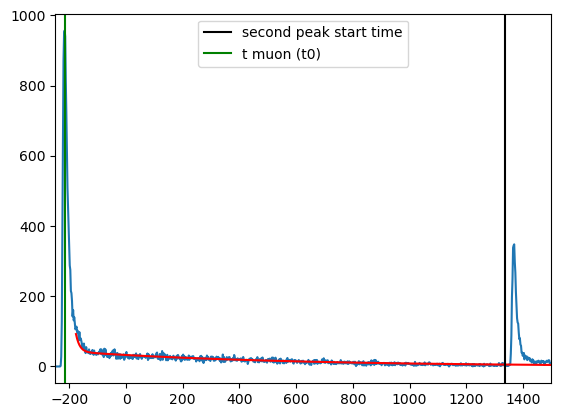

In [19]:
plt.plot(x[4500:6500], y[4500:6500])
plt.plot(x_axis,test(x_axis,param1[0],param1[1],param1[2]),'r') #plotting the test function
plt.axvline(1337.4171771471447, color = 'k', label = "second peak start time") #plot the starting point for the second peak for integration
plt.axvline(-216.77709713714103, color = 'green', label = "t muon (t0)")
plt.xlim(-250, 1500)
plt.legend()
plt.show()

In [39]:
#Integrate the plot above by finding the starting point of the second peak, which is the starting point for three consecutive slopes before the second peak
#and subtracting the red exponential from the second peak for (40 and 90 ns) 2 ns equals a bin 

#Loop to find the starting point of the secondary peak
#o = np.arange(0, len(x)-1);
#for i in o:
 #   if y[i] > y[i-1] and y[i] < y[i+1] and y[i] < y2max and x[i] > 1000:
  #      print(x[i] , y[i], i)
#Based on the above code the starting point of the secondary peak should be (1337.4171771471447, 2.3070671558380127)

#Loop to find the starting point of the primary peak (t0) which is t muon for the fitting equation below
#o = np.arange(0, len(x)-1);
#for i in o:
 #   if y[i] == np.max(y):
         #print(x[i] , y[i], i)
#Based on the above code the starting point of the primary peak should be (-216.77709713714103, 956.901932477951)
t0 = -216.77709713714103

#Integrate for 20 bins
bins = np.arange(1337, 1356)
sum = 0
for i in bins:
   # print(y[i+4500])
    sum += y[i+4500] - (apara*np.exp(-(i-t0)/tspara) + bpara*np.exp(-(i-t0)/743.))
print("Number of PEs (photoelectron):",sum)

#Integrate for 45 bins
bins2 = np.arange(1337, 1381)
sum2 = 0
for i in bins2:
   # print(y[i+4500])
    sum2 += y[i+4500] - (apara*np.exp(-(i-t0)/tspara) + bpara*np.exp(-(i-t0)/743.))
print("Number of PEs (photoelectron):",sum2)


Number of PEs (photoelectron): 87.32202849226147
Number of PEs (photoelectron): 158.9025610134482


In [25]:
#Define function for fitting the muon track, where tt is undefined
def test2(t,a,b,ts,tt):
    return (np.heaviside(t-t0, 1.))*a*np.exp(-(t-t0)/ts) + (np.heaviside(t-t0,1.))*b*np.exp(-(t-t0)/tt)

In [27]:
#Design curve fit based on above function and muon data
param2, param_cov2 = curve_fit(test2, x[loc_max+1:loc2_max-15], y[loc_max+1:loc2_max-15])
print(param2)
print(param_cov2)

[1034.88029256   47.75040213   13.07789604  637.06479321]
[[ 2.70729029e+01  8.60106386e-02 -3.43564982e-01 -6.11863654e-01]
 [ 8.60106386e-02  6.21875413e-01 -2.98775121e-02 -9.05000547e+00]
 [-3.43564982e-01 -2.98775121e-02  8.82806529e-03  4.14638921e-01]
 [-6.11863654e-01 -9.05000547e+00  4.14638921e-01  2.14637020e+02]]


In [29]:
#Display parameters associated with each value for the function
print("a = ", param2[0], " +/- ", param_cov2[0][0]) 
print("b = ", param2[1], " +/- ", param_cov2[1][1])
print("ts = ", param2[2], " +/- ", param_cov2[2][2])
print("tt = ", param2[3], " +/- ", param_cov2[3][3])
apara2 = param2[0]
bpara2 = param2[1]
tspara2 = param2[2]
ttpara = param2[3]

a =  1034.880292564665  +/-  27.07290287455417
b =  47.75040212624421  +/-  0.6218754128775689
ts =  13.077896040050433  +/-  0.008828065294200625
tt =  637.0647932137736  +/-  214.6370196532425


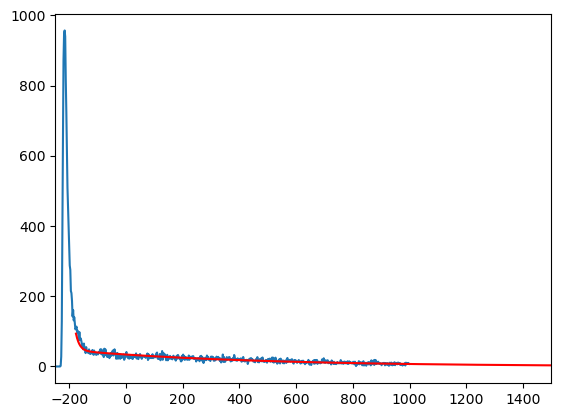

In [31]:
plt.plot(x[4500:5500], y[4500:5500])
plt.plot(x_axis, test2(x_axis,param2[0],param2[1], param2[2], param2[3]),'r') #plotting the test function
#plt.axvline(1337.4171771471447, color = 'k', label = "second peak start time") #plot the starting point for the second peak for integration
#plt.axvline(-216.77709713714103, color = 'green', label = "t muon (t0)")
#plt.legend()
plt.xlim(-250, 1500)
plt.show()

In [37]:
#Integrate the plot above by finding the starting point of the second peak, which is the starting point for three consecutive slopes before the second peak
#and subtracting the red exponential from the second peak for (40 and 90 ns) 2 ns equals a bin 

#Loop to find the starting point of the secondary peak
#o = np.arange(0, len(x)-1);
#for i in o:
 #   if y[i] > y[i-1] and y[i] < y[i+1] and y[i] < y2max and x[i] > 1000:
  #      print(x[i] , y[i], i)
#Based on the above code the starting point of the secondary peak should be (1337.4171771471447, 2.3070671558380127)

#Loop to find the starting point of the primary peak (t0) which is t muon for the fitting equation below
#o = np.arange(0, len(x)-1);
#for i in o:
 #   if y[i] == np.max(y):
         #print(x[i] , y[i], i)
#Based on the above code the starting point of the primary peak should be (-216.77709713714103, 956.901932477951)
#t02 = -216.77709713714103


#bins3 = np.arange(1337, 1356)
sum3 = 0
for i in bins:
   # print(y[i+4500])
    sum3 += y[i+4500] - (apara2*np.exp(-(i-t0)/tspara2) + bpara2*np.exp(-(i-t0)/ttpara))
print("Number of PEs (photoelectron):",sum3)

sum4 = 0
for i in bins2:
    sum4 += y[i+4500] - (apara2*np.exp(-(i-t0)/tspara2) + bpara2*np.exp(-(i-t0)/ttpara))
print("Number of PEs (photoelectron):", sum4)

Number of PEs (photoelectron): 110.7476623720923
Number of PEs (photoelectron): 212.74170773088855
